In [20]:
from __future__ import annotations

import os, glob
import re
import argparse
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from scipy.signal import hilbert

from pathlib import Path
import json
import pandas as pd

In [11]:
# ===========================
# Params
# ===========================

@dataclass
class Params:
    # Envelope smoothing (ms)
    env_smooth_ms: float = 3.0

    # Robust z-threshold for envelope
    z_thresh: float = 5.0

    # Event duration constraints (ms)
    min_dur_ms: float = 6.0
    max_dur_ms: float = 200.0

    # Merge events separated by small gaps (ms)
    merge_gap_ms: float = 10.0

    # FRandR tolerance (ms): overlap or within tolerance
    frandr_ms: float = 30.0

    # Optional: only keep iEEG-like channels (by name heuristic)
    filter_ieeg_only: bool = False

    # HFO-area heuristic
    hfo_area_percentile: float = 95.0
    hfo_area_positive_only: bool = True

In [12]:
# ===========================
# Utilities
# ===========================

def moving_average(x: np.ndarray, win: int) -> np.ndarray:
    if win <= 1:
        return x
    k = np.ones(win, dtype=np.float64) / win
    return np.convolve(x, k, mode="same")


def robust_z(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    return 0.6745 * (x - med) / mad


def segments_from_mask(mask: np.ndarray) -> List[Tuple[int, int]]:
    idx = np.flatnonzero(mask.astype(np.int8))
    if idx.size == 0:
        return []
    segs = []
    s = idx[0]
    prev = idx[0]
    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            segs.append((s, prev + 1))
            s = k
            prev = k
    segs.append((s, prev + 1))
    return segs


def merge_close_segments(segs: List[Tuple[int, int]], gap: int) -> List[Tuple[int, int]]:
    if not segs:
        return []
    segs = sorted(segs, key=lambda t: t[0])
    merged = [segs[0]]
    for s, e in segs[1:]:
        ps, pe = merged[-1]
        if s - pe <= gap:
            merged[-1] = (ps, max(pe, e))
        else:
            merged.append((s, e))
    return merged


def infer_run_prefix(path_ripple: str) -> str:
    base = os.path.basename(path_ripple)
    m = re.match(r"(.+?)_ripple_epo\.fif$", base)
    if not m:
        raise ValueError(f"Cannot infer run prefix from: {base}")
    return m.group(1)


def discover_runs(root: str) -> List[Tuple[str, str]]:
    """
    Find matching (ripple_epo, fast_epo) pairs under root.
    """
    ripple_files = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.endswith("_ripple_epo.fif"):
                ripple_files.append(os.path.join(dirpath, fn))

    pairs = []
    for rip in sorted(ripple_files):
        fast = rip.replace("_ripple_epo.fif", "_fast_epo.fif")
        if os.path.exists(fast):
            pairs.append((rip, fast))
        else:
            print(f"[WARN] Missing fast epochs for: {rip}")
    return pairs

In [15]:
# ===========================
# HFO detection
# ===========================

def detect_events_from_epochs(
    epo: mne.Epochs,
    band_name: str,
    params: Params,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Detect events in band-specific epochs using Hilbert envelope + robust z threshold.
    Adds epoch_start (absolute sample start from epo.events[:,0]).
    """
    data = epo.get_data()  # (n_epochs, n_channels, n_times)
    fs = float(epo.info["sfreq"])
    ch_names = list(epo.ch_names)

    if params.filter_ieeg_only:
        picks = pick_ieeg_channels(ch_names)
        data = data[:, picks, :]
        ch_names = [ch_names[i] for i in picks]

    n_ep, n_ch, _ = data.shape

    env_win = max(1, int(params.env_smooth_ms * fs / 1000.0))
    merge_gap = max(0, int(params.merge_gap_ms * fs / 1000.0))
    min_len = max(1, int(params.min_dur_ms * fs / 1000.0))
    max_len = max(1, int(params.max_dur_ms * fs / 1000.0))

    epoch_starts = epo.events[:, 0]

    rows = []
    qc_rows = []

    for ei in range(n_ep):
        ev_count = 0
        ep_start = int(epoch_starts[ei])

        for ci in range(n_ch):
            x = data[ei, ci].astype(np.float64, copy=False)

            env = np.abs(hilbert(x))
            env = moving_average(env, env_win)

            z = robust_z(env)
            mask = z >= params.z_thresh

            segs = merge_close_segments(segments_from_mask(mask), merge_gap)

            for s, e in segs:
                L = e - s
                if L < min_len or L > max_len:
                    continue

                pk = s + int(np.argmax(z[s:e]))
                ev_count += 1

                rows.append(
                    {
                        "epoch": int(ei),                 # local index after any alignment
                        "epoch_start": ep_start,          # absolute start sample
                        "band": band_name,
                        "channel": ch_names[ci],
                        "start_samp": int(s),
                        "end_samp": int(e),
                        "peak_samp": int(pk),
                        "peak_z": float(z[pk]),
                        "start_sec": float(s / fs),
                        "end_sec": float(e / fs),
                        "peak_sec": float(pk / fs),
                    }
                )

        qc_rows.append({"epoch": int(ei), "epoch_start": ep_start, f"n_{band_name}": int(ev_count)})

    return pd.DataFrame(rows), pd.DataFrame(qc_rows)


def label_frandr(
    ripple_events: pd.DataFrame,
    fr_events: pd.DataFrame,
    fs: float,
    frandr_ms: float,
) -> pd.DataFrame:
    """
    FRandR pairs: match ripple <-> fr in same epoch_start+channel if overlap within tolerance.
    """
    cols = ["epoch_start", "channel", "ripple_event_id", "fr_event_id", "delta_ms"]
    if ripple_events.empty or fr_events.empty:
        return pd.DataFrame(columns=cols)

    tol = int(frandr_ms * fs / 1000.0)

    rip = ripple_events.reset_index(drop=False).rename(columns={"index": "ripple_event_id"})
    fr = fr_events.reset_index(drop=False).rename(columns={"index": "fr_event_id"})

    out_rows = []

    for (epoch_start, ch), rip_g in rip.groupby(["epoch_start", "channel"]):
        fr_g = fr[(fr["epoch_start"] == epoch_start) & (fr["channel"] == ch)]
        if fr_g.empty:
            continue

        fr_st = fr_g["start_samp"].to_numpy()
        fr_en = fr_g["end_samp"].to_numpy()
        fr_pk = fr_g["peak_samp"].to_numpy()
        fr_id = fr_g["fr_event_id"].to_numpy()

        for _, r in rip_g.iterrows():
            rs, re = int(r["start_samp"]), int(r["end_samp"])
            rpk = int(r["peak_samp"])

            ok = ~((fr_en < (rs - tol)) | (fr_st > (re + tol)))
            if not np.any(ok):
                continue

            cand_pk = fr_pk[ok]
            cand_id = fr_id[ok]

            best_j = int(np.argmin(np.abs(cand_pk - rpk)))
            best_fr_id = int(cand_id[best_j])

            delta_ms = float((int(cand_pk[best_j]) - rpk) / fs * 1000.0)

            out_rows.append(
                {
                    "epoch_start": int(epoch_start),
                    "channel": str(ch),
                    "ripple_event_id": int(r["ripple_event_id"]),
                    "fr_event_id": best_fr_id,
                    "delta_ms": delta_ms,
                }
            )

    return pd.DataFrame(out_rows, columns=cols)


def compute_rates_per_min(
    events_df: pd.DataFrame,
    epoch_len_sec: float,
    n_epochs: int,
    band_label: str,
) -> pd.DataFrame:
    total_min = (epoch_len_sec * n_epochs) / 60.0
    if total_min <= 0:
        raise ValueError("Total minutes must be > 0")

    if events_df.empty:
        return pd.DataFrame(columns=["channel", "band", "count", "rate_per_min"])

    grp = events_df.groupby("channel", as_index=False).size().rename(columns={"size": "count"})
    grp["band"] = band_label
    grp["rate_per_min"] = grp["count"] / total_min
    return grp[["channel", "band", "count", "rate_per_min"]]


def hfo_area_by_percentile(
    rates_df: pd.DataFrame,
    band: str = "fr",
    percentile: float = 95.0,
    positive_only: bool = True,
) -> pd.DataFrame:
    """
    Mark channels whose rate exceeds patient-specific percentile.
    If positive_only=True, compute percentile over strictly positive rates (avoids threshold=0 issues).
    """
    df = rates_df[rates_df["band"] == band].copy()
    if df.empty:
        df["threshold"] = np.nan
        df["is_hfo_area"] = False
        return df

    vals = df["rate_per_min"].to_numpy()
    if positive_only:
        vals_pos = vals[vals > 0]
        if vals_pos.size == 0:
            df["threshold"] = 0.0
            df["is_hfo_area"] = False
            return df
        thr = float(np.percentile(vals_pos, percentile))
    else:
        thr = float(np.percentile(vals, percentile))

    df["threshold"] = thr
    df["is_hfo_area"] = df["rate_per_min"] >= thr
    return df


In [16]:
# ----------------------------
# Run processing
# ----------------------------

def process_run(ripple_path: str, fast_path: str, params: Params, out_dir: Optional[str] = None) -> None:
    ripple_epo = mne.read_epochs(ripple_path, preload=True, verbose="ERROR")
    fast_epo = mne.read_epochs(fast_path, preload=True, verbose="ERROR")

    # --- Check sampling rate
    if float(ripple_epo.info["sfreq"]) != float(fast_epo.info["sfreq"]):
        raise ValueError("Sampling rate mismatch between ripple and fast epochs.")
    fs = float(ripple_epo.info["sfreq"])

    # --- Align epochs by epoch start sample (events[:,0]) to handle band-specific artifact drops
    rip_starts = ripple_epo.events[:, 0]
    fast_starts = fast_epo.events[:, 0]

    common = np.intersect1d(rip_starts, fast_starts)
    if common.size == 0:
        raise ValueError("No common epoch start samples between ripple and fast epochs.")

    ripple_epo = ripple_epo[np.isin(rip_starts, common)]
    fast_epo = fast_epo[np.isin(fast_starts, common)]

    # --- After alignment, check time axis
    if ripple_epo.get_data().shape[2] != fast_epo.get_data().shape[2]:
        raise ValueError("n_times mismatch between ripple and fast epochs after alignment.")

    n_epochs = len(ripple_epo)
    if n_epochs != len(fast_epo):
        raise RuntimeError("Alignment failed: still different epoch counts (unexpected).")

    # epoch length (seconds)
    epoch_len_sec = float(ripple_epo.times[-1] - ripple_epo.times[0])

    # --- Detect events
    rip_events, rip_qc = detect_events_from_epochs(ripple_epo, "ripple", params)
    fr_events, fr_qc = detect_events_from_epochs(fast_epo, "fr", params)

    # --- QC merge
    qc = pd.DataFrame({"epoch": np.arange(n_epochs), "epoch_start": ripple_epo.events[:, 0].astype(int)})
    if not rip_qc.empty:
        qc = qc.merge(rip_qc, on=["epoch", "epoch_start"], how="left")
    if not fr_qc.empty:
        qc = qc.merge(fr_qc, on=["epoch", "epoch_start"], how="left")
    qc = qc.fillna(0)
    for c in qc.columns:
        if c.startswith("n_"):
            qc[c] = qc[c].astype(int)

    # --- FRandR pairs (matches by epoch_start+channel)
    frandr_pairs = label_frandr(rip_events, fr_events, fs, params.frandr_ms)

    # --- Add ids for traceability and merge tables
    rip_events = rip_events.reset_index(drop=False).rename(columns={"index": "event_id"})
    fr_events = fr_events.reset_index(drop=False).rename(columns={"index": "event_id"})
    all_events = pd.concat([rip_events, fr_events], ignore_index=True)

    # --- Rates
    rates_rip = compute_rates_per_min(rip_events, epoch_len_sec, n_epochs, "ripple")
    rates_fr = compute_rates_per_min(fr_events, epoch_len_sec, n_epochs, "fr")

    # FRandR "rate": count pairs per channel
    if frandr_pairs.empty:
        rates_frandr = pd.DataFrame(columns=["channel", "band", "count", "rate_per_min"])
    else:
        tmp = frandr_pairs.groupby("channel", as_index=False).size().rename(columns={"size": "count"})
        total_min = (epoch_len_sec * n_epochs) / 60.0
        tmp["band"] = "frandr"
        tmp["rate_per_min"] = tmp["count"] / total_min
        rates_frandr = tmp[["channel", "band", "count", "rate_per_min"]]

    rates = pd.concat([rates_rip, rates_fr, rates_frandr], ignore_index=True)

    # --- HFO area heuristic
    fr_area = hfo_area_by_percentile(
        rates, band="fr", percentile=params.hfo_area_percentile, positive_only=params.hfo_area_positive_only
    )
    frandr_area = hfo_area_by_percentile(
        rates, band="frandr", percentile=params.hfo_area_percentile, positive_only=params.hfo_area_positive_only
    )

    # --- Write outputs
    prefix = infer_run_prefix(ripple_path)
    if out_dir is None:
        out_dir = os.path.dirname(ripple_path)
    os.makedirs(out_dir, exist_ok=True)

    events_out = os.path.join(out_dir, f"{prefix}_hfo_detect_events.csv")
    pairs_out = os.path.join(out_dir, f"{prefix}_hfo_detect_frandr_pairs.csv")
    rates_out = os.path.join(out_dir, f"{prefix}_hfo_detect_rates.csv")
    qc_out = os.path.join(out_dir, f"{prefix}_hfo_detect_qc.csv")
    fr_area_out = os.path.join(out_dir, f"{prefix}_hfo_area_fr_{int(params.hfo_area_percentile)}p.csv")
    frandr_area_out = os.path.join(out_dir, f"{prefix}_hfo_area_frandr_{int(params.hfo_area_percentile)}p.csv")

    all_events.to_csv(events_out, index=False)
    frandr_pairs.to_csv(pairs_out, index=False)
    rates.to_csv(rates_out, index=False)
    qc.to_csv(qc_out, index=False)
    fr_area.to_csv(fr_area_out, index=False)
    frandr_area.to_csv(frandr_area_out, index=False)

    print(f"[OK] {prefix} | aligned_epochs={n_epochs}")
    print(f"  Events: {len(all_events)} (ripple={len(rip_events)}, fr={len(fr_events)}) | FRandR pairs={len(frandr_pairs)}")
    print(f"  Wrote:\n    {events_out}\n    {pairs_out}\n    {rates_out}\n    {qc_out}\n    {fr_area_out}\n    {frandr_area_out}")

In [17]:
# ===========================
# RUN
# ===========================

ROOT = r"D:\derivatives\preproc_ds003498"   # your derivatives root
OUT_DIR = r"D:\derivatives\preproc_ds003498\hfo_detect_out" 

params = Params(
    env_smooth_ms=3.0,
    z_thresh=5.0,
    min_dur_ms=6.0,
    max_dur_ms=200.0,
    merge_gap_ms=10.0,
    frandr_ms=30.0,
    filter_ieeg_only=False,
    hfo_area_percentile=95.0,
    hfo_area_positive_only=True,
)

pairs = discover_runs(ROOT)
print(f"Found {len(pairs)} run(s).")

# For debugging, you can restrict to one subject/run:
# pairs = [p for p in pairs if ("sub-01" in p[0] and "run-01" in p[0])]

for ripple_path, fast_path in pairs:
    process_run(ripple_path, fast_path, params, out_dir=OUT_DIR)


Found 382 run(s).
[OK] sub-01_ses-interictalsleep_run-01 | aligned_epochs=57
  Events: 5085 (ripple=4737, fr=348) | FRandR pairs=352
  Wrote:
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_detect_events.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_detect_frandr_pairs.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_detect_rates.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_detect_qc.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_area_fr_95p.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_area_frandr_95p.csv
[OK] sub-01_ses-interictalsleep_run-02 | aligned_epochs=57
  Events: 4122 (ripple=3846, fr=276) | FRandR pairs=238
  Wrote:
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-02_hfo_de

C:\Users\ajars\AppData\Local\Temp\ipykernel_22056\2613425324.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rates = pd.concat([rates_rip, rates_fr, rates_frandr], ignore_index=True)


[OK] sub-10_ses-interictalsleep_run-05 | aligned_epochs=58
  Events: 1937 (ripple=1930, fr=7) | FRandR pairs=0
  Wrote:
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_detect_events.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_detect_frandr_pairs.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_detect_rates.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_detect_qc.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_area_fr_95p.csv
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-05_hfo_area_frandr_95p.csv
[OK] sub-10_ses-interictalsleep_run-06 | aligned_epochs=58
  Events: 1741 (ripple=1719, fr=22) | FRandR pairs=3
  Wrote:
    D:\derivatives\preproc_ds003498\hfo_detect_out\sub-10_ses-interictalsleep_run-06_hfo_detect_events.csv
    D:\de

In [25]:
OUT = r"D:\derivatives\preproc_ds003498\hfo_detect_out"

def load_run(prefix: str, out_dir: str = OUT):
    def r(path):
        return pd.read_csv(path) if os.path.exists(path) else pd.DataFrame()

    base = os.path.join(out_dir, prefix)
    D = {
        "events": r(base + "_hfo_detect_events.csv"),
        "pairs":  r(base + "_hfo_detect_frandr_pairs.csv"),
        "qc":     r(base + "_hfo_detect_qc.csv"),
        "rates":  r(base + "_hfo_detect_rates.csv"),
        "fr_area": r(base + "_hfo_area_fr_95p.csv"),
        "frandr_area": r(base + "_hfo_area_frandr_95p.csv"),
    }
    return D

prefix = "sub-01_ses-interictalsleep_run-01"
D = load_run(prefix)

{k: df.shape for k, df in D.items()}


{'events': (5085, 12),
 'pairs': (352, 5),
 'qc': (57, 4),
 'rates': (101, 4),
 'fr_area': (26, 6),
 'frandr_area': (25, 6)}

In [26]:
rates = D["rates"]

def show_top(band, k=15):
    df = rates[rates["band"]==band].sort_values("rate_per_min", ascending=False).head(k)
    print(f"\nTop {k} channels by {band} rate:")
    display(df)

show_top("fr", 15)
show_top("frandr", 15)
show_top("ripple", 15)



Top 15 channels by fr rate:


,channel,band,count,rate_per_min
68,PHR1,fr,97,20.421053
69,PHR2,fr,50,10.526316
51,AHR2,fr,31,6.526316
75,PHR8,fr,31,6.526316
57,AR2,fr,31,6.526316
50,AHR1,fr,30,6.315789
74,PHR7,fr,14,2.947368
56,AR1,fr,12,2.526316
58,AR3,fr,9,1.894737
70,PHR3,fr,7,1.473684



Top 15 channels by frandr rate:


,channel,band,count,rate_per_min
93,PHR1,frandr,97,20.421053
94,PHR2,frandr,51,10.736842
100,PHR8,frandr,36,7.578947
76,AHR1,frandr,31,6.526316
82,AR2,frandr,30,6.315789
77,AHR2,frandr,29,6.105263
99,PHR7,frandr,15,3.157895
81,AR1,frandr,12,2.526316
83,AR3,frandr,9,1.894737
95,PHR3,frandr,7,1.473684



Top 15 channels by ripple rate:


,channel,band,count,rate_per_min
17,AR2,ripple,354,74.526316
16,AR1,ripple,250,52.631579
42,PHR1,ripple,238,50.105263
1,AHR2,ripple,229,48.210526
18,AR3,ripple,194,40.842105
5,AHR6,ripple,188,39.578947
0,AHR1,ripple,184,38.736842
19,AR4,ripple,182,38.315789
7,AHR8,ripple,180,37.894737
43,PHR2,ripple,173,36.421053


In [27]:
def concentration_metrics(rates_df, band):
    df = rates_df[rates_df["band"]==band].copy()
    if df.empty:
        return {"band": band, "n_ch": 0, "sum_rate": 0, "top5_share": np.nan, "gini": np.nan}
    vals = np.sort(df["rate_per_min"].to_numpy())
    s = vals.sum()
    top5_share = vals[-5:].sum()/s if s>0 and len(vals)>=5 else np.nan

    # Gini coefficient
    if s <= 0:
        gini = np.nan
    else:
        x = vals
        n = len(x)
        gini = (2*np.sum((np.arange(1,n+1))*x)/(n*s)) - (n+1)/n

    return {"band": band, "n_ch": len(vals), "sum_rate": s, "top5_share": top5_share, "gini": gini}

for b in ["fr", "frandr", "ripple"]:
    print(concentration_metrics(rates, b))


{'band': 'fr', 'n_ch': 26, 'sum_rate': np.float64(73.26315789473684), 'top5_share': np.float64(0.6896551724137931), 'gini': np.float64(0.6750663129973475)}
{'band': 'frandr', 'n_ch': 25, 'sum_rate': np.float64(74.10526315789474), 'top5_share': np.float64(0.6960227272727273), 'gini': np.float64(0.6706818181818179)}
{'band': 'ripple', 'n_ch': 50, 'sum_rate': np.float64(997.2631578947369), 'top5_share': np.float64(0.2670466540004222), 'gini': np.float64(0.43090985856027)}


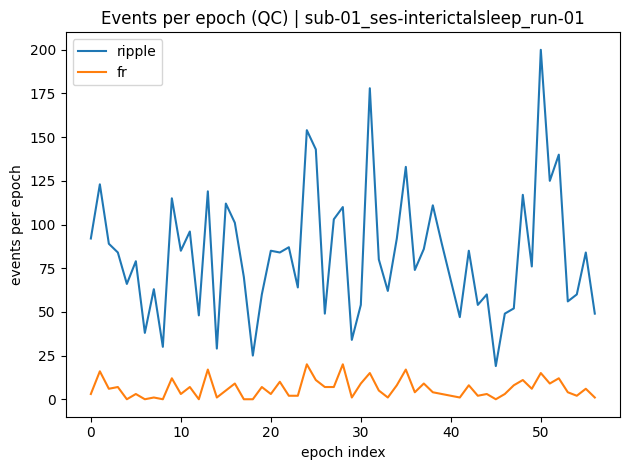

,epoch,epoch_start,n_ripple,n_fr
50,50,520000,200,15
31,31,320000,178,15
24,24,250000,154,20
25,25,260000,143,11
52,52,540000,140,12
35,35,360000,133,17
51,51,530000,125,9
1,1,20000,123,16
13,13,140000,119,17
48,48,500000,117,11


In [28]:
qc = D["qc"]
plt.figure()
if "n_ripple" in qc.columns: plt.plot(qc["epoch"], qc["n_ripple"], label="ripple")
if "n_fr" in qc.columns: plt.plot(qc["epoch"], qc["n_fr"], label="fr")
plt.xlabel("epoch index")
plt.ylabel("events per epoch")
plt.title(f"Events per epoch (QC) | {prefix}")
plt.legend()
plt.tight_layout()
plt.show()

# Show worst epochs
cols = [c for c in qc.columns if c.startswith("n_")]
if cols:
    display(qc.sort_values(cols, ascending=False).head(10))


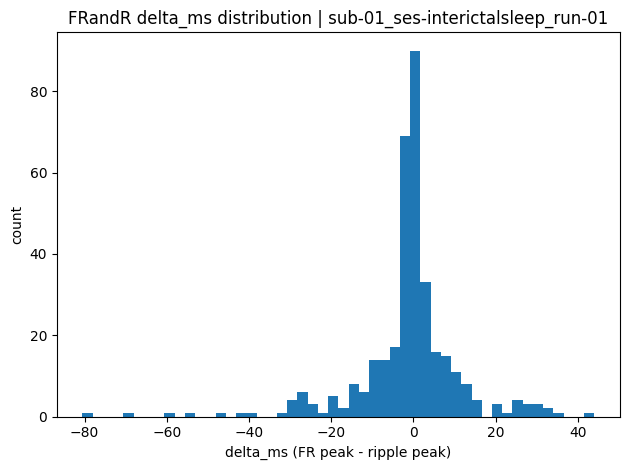

delta_ms stats: count    352.000000
mean      -1.201705
std       13.226622
min      -80.500000
25%       -3.125000
50%       -0.500000
75%        3.000000
max       44.000000
Name: delta_ms, dtype: float64


In [29]:
pairs = D["pairs"]
if not pairs.empty:
    plt.figure()
    plt.hist(pairs["delta_ms"].to_numpy(), bins=50)
    plt.xlabel("delta_ms (FR peak - ripple peak)")
    plt.ylabel("count")
    plt.title(f"FRandR delta_ms distribution | {prefix}")
    plt.tight_layout()
    plt.show()

    print("delta_ms stats:", pairs["delta_ms"].describe())
else:
    print("No FRandR pairs for this run.")


In [30]:
fr_area = D["fr_area"]
frandr_area = D["frandr_area"]

def show_area(area_df, name):
    if area_df.empty:
        print(name, "empty")
        return
    thr = float(area_df["threshold"].iloc[0])
    picked = area_df[area_df["is_hfo_area"]==True].sort_values("rate_per_min", ascending=False)
    print(f"{name}: threshold={thr:.4f}, selected_channels={len(picked)}/{len(area_df)}")
    display(picked)

show_area(fr_area, "FR area 95p")
show_area(frandr_area, "FRandR area 95p")


FR area 95p: threshold=9.5263, selected_channels=2/26


,channel,band,count,rate_per_min,threshold,is_hfo_area
18,PHR1,fr,97,20.421053,9.526316,True
19,PHR2,fr,50,10.526316,9.526316,True


FRandR area 95p: threshold=10.1053, selected_channels=2/25


,channel,band,count,rate_per_min,threshold,is_hfo_area
17,PHR1,frandr,97,20.421053,10.105263,True
18,PHR2,frandr,51,10.736842,10.105263,True


In [31]:
# analysis across all runs
import glob, re, os

event_files = sorted(glob.glob(os.path.join(OUT, "*_hfo_detect_events.csv")))
prefixes = [re.sub(r"_hfo_detect_events\.csv$", "", os.path.basename(f)) for f in event_files]
print("Runs found:", len(prefixes))
prefixes[:5]

def parse_prefix(prefix):
    # sub-01_ses-interictalsleep_run-01
    m = re.match(r"sub-(\d+)_ses-([^_]+)_run-(\d+)", prefix)
    if not m:
        return None, None, None
    return m.group(1), m.group(2), m.group(3)

rows = []
for pref in prefixes:
    D0 = load_run(pref)

    rates = D0["rates"]
    pairs = D0["pairs"]
    events = D0["events"]

    sub, ses, run = parse_prefix(pref)

    # concentration metrics
    fr_m = concentration_metrics(rates, "fr")
    frandr_m = concentration_metrics(rates, "frandr")

    rows.append({
        "prefix": pref,
        "subject": sub,
        "session": ses,
        "run": run,
        "n_events": len(events),
        "n_pairs_frandr": len(pairs),
        "fr_sum_rate": fr_m["sum_rate"],
        "fr_top5_share": fr_m["top5_share"],
        "fr_gini": fr_m["gini"],
        "frandr_sum_rate": frandr_m["sum_rate"],
        "frandr_top5_share": frandr_m["top5_share"],
        "frandr_gini": frandr_m["gini"],
    })

summary = pd.DataFrame(rows)
summary.head()



Runs found: 382


,prefix,subject,session,run,n_events,n_pairs_frandr,fr_sum_rate,fr_top5_share,fr_gini,frandr_sum_rate,frandr_top5_share,frandr_gini
0,sub-01_ses-interictalsleep_run-01,01,interictalsleep,01,5085,352,73.263158,0.689655,0.675066,74.105263,0.696023,0.670682
1,sub-01_ses-interictalsleep_run-02,01,interictalsleep,02,4122,238,58.105263,0.659420,0.692982,50.105263,0.777311,0.728691
2,sub-01_ses-interictalsleep_run-03,01,interictalsleep,03,4037,250,52.071429,0.823045,0.684271,53.571429,0.836000,0.650133
3,sub-01_ses-interictalsleep_run-04,01,interictalsleep,04,3958,255,58.928571,0.734545,0.710616,54.642857,0.784314,0.677871
4,sub-01_ses-interictalsleep_run-05,01,interictalsleep,05,3267,181,38.315789,0.912088,0.663004,38.105263,0.911602,0.634857


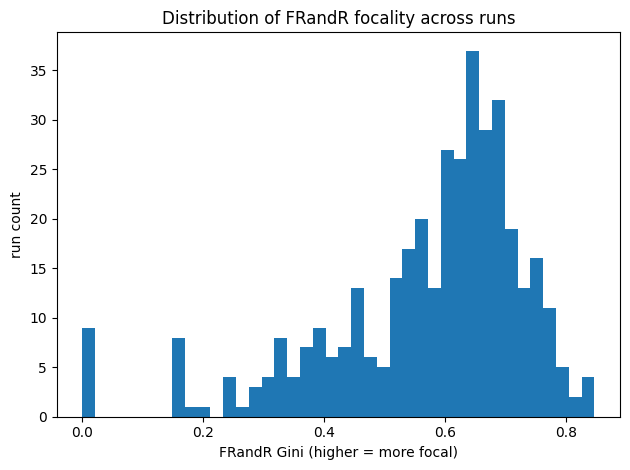

In [32]:
plt.figure()
vals = summary["frandr_gini"].dropna().to_numpy()
plt.hist(vals, bins=40)
plt.xlabel("FRandR Gini (higher = more focal)")
plt.ylabel("run count")
plt.title("Distribution of FRandR focality across runs")
plt.tight_layout()
plt.show()


In [33]:
from collections import Counter

def load_frandr_area_channels(prefix):
    path = os.path.join(OUT, prefix + "_hfo_area_frandr_95p.csv")
    if not os.path.exists(path):
        return []
    df = pd.read_csv(path)
    return df.loc[df["is_hfo_area"]==True, "channel"].astype(str).tolist()

# Example: sub-01 only
sub = "01"
sub_prefixes = [p for p in prefixes if p.startswith(f"sub-{sub}_")]
cnt = Counter()
for p in sub_prefixes:
    cnt.update(load_frandr_area_channels(p))

top = cnt.most_common(20)
top[:10]


[('PHR1', 28),
 ('PHR2', 9),
 ('HL6', 3),
 ('AHR8', 2),
 ('AR2', 2),
 ('AHR1', 2),
 ('IPR3', 1),
 ('AHR2', 1)]

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np


def _safe_float(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except Exception:
        return None


def _safe_int(x):
    if pd.isna(x):
        return None
    try:
        return int(x)
    except Exception:
        return None


def _safe_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(x)
    s = str(x).strip().lower()
    return s in {"true", "1", "yes", "y"}


def _sort_top_channels(df, band=None, top_k=5):
    tmp = df.copy()
    if band is not None:
        tmp = tmp[tmp["band"].astype(str).str.lower() == band.lower()].copy()

    if tmp.empty:
        return []

    tmp = tmp.sort_values(["rate_per_min", "count", "channel"], ascending=[False, False, True])
    return tmp["channel"].astype(str).head(top_k).tolist()


def build_hfo_case_summary(
    fr_area_csv,
    frandr_area_csv,
    detect_rates_csv,
    output_json,
    patient_id=None,
    recording_id=None,
    dataset="OpenNeuro_ds003498",
    top_k=5,
    preprocessing=None,
):
    """
    Build a compact HFO JSON summary for LLM Phase 1.

    Inputs
    ------
    fr_area_csv : path to hfo_area_fr_95p*.csv
    frandr_area_csv : path to hfo_area_frandr_95p*.csv
    detect_rates_csv : path to hfo_detect_rates*.csv
    output_json : path to output json
    patient_id : optional, inferred from filename if None
    recording_id : optional, inferred from filename if None
    dataset : dataset label
    top_k : number of top channels to keep
    preprocessing : optional dict with preprocessing info
    """

    fr_area_csv = Path(fr_area_csv)
    frandr_area_csv = Path(frandr_area_csv)
    detect_rates_csv = Path(detect_rates_csv)
    output_json = Path(output_json)

    fr_df = pd.read_csv(fr_area_csv)
    frandr_df = pd.read_csv(frandr_area_csv)
    rates_df = pd.read_csv(detect_rates_csv)

    # ---------- Infer patient / recording IDs ----------
    if patient_id is None:
        # example filename: sub-01_ses-interictalsleep_run-01_hfo_area_fr_95p.csv
        stem = fr_area_csv.stem
        parts = stem.split("_")
        patient_id = parts[0] if len(parts) > 0 else "unknown"

    if recording_id is None:
        stem = fr_area_csv.stem
        suffix = "_hfo_area_fr_95p"
        recording_id = stem.replace(f"{patient_id}_", "").replace(suffix, "")
        if recording_id == stem:
            recording_id = "unknown_recording"

    # ---------- Normalize columns ----------
    for df in [fr_df, frandr_df, rates_df]:
        df.columns = [c.strip() for c in df.columns]

    # Make sure required columns exist
    required_fr_cols = {"channel", "band", "count", "rate_per_min", "threshold", "is_hfo_area"}
    required_rates_cols = {"channel", "band", "count", "rate_per_min"}

    missing_fr = required_fr_cols - set(fr_df.columns)
    missing_frandr = required_fr_cols - set(frandr_df.columns)
    missing_rates = required_rates_cols - set(rates_df.columns)

    if missing_fr:
        raise ValueError(f"Missing columns in FR area CSV: {missing_fr}")
    if missing_frandr:
        raise ValueError(f"Missing columns in FRandR area CSV: {missing_frandr}")
    if missing_rates:
        raise ValueError(f"Missing columns in detect rates CSV: {missing_rates}")

    # ---------- Top channels from detect_rates ----------
    top_ripple_channels = _sort_top_channels(rates_df, band="ripple", top_k=top_k)
    top_fr_channels_from_rates = _sort_top_channels(rates_df, band="fr", top_k=top_k)

    # ---------- FR-defined HFO area ----------
    fr_df["is_hfo_area"] = fr_df["is_hfo_area"].apply(_safe_bool)
    fr_area_only = fr_df[fr_df["is_hfo_area"]].copy()
    fr_area_channels = fr_area_only["channel"].astype(str).tolist()

    fr_threshold = None
    if not fr_df.empty and "threshold" in fr_df.columns:
        vals = fr_df["threshold"].dropna().unique().tolist()
        fr_threshold = _safe_float(vals[0]) if len(vals) > 0 else None

    top_fr_channels_area = (
        fr_df.sort_values(["rate_per_min", "count", "channel"], ascending=[False, False, True])["channel"]
        .astype(str).head(top_k).tolist()
    )

    # ---------- FRandR-defined HFO area ----------
    frandr_df["is_hfo_area"] = frandr_df["is_hfo_area"].apply(_safe_bool)
    frandr_area_only = frandr_df[frandr_df["is_hfo_area"]].copy()
    frandr_area_channels = frandr_area_only["channel"].astype(str).tolist()

    frandr_threshold = None
    if not frandr_df.empty and "threshold" in frandr_df.columns:
        vals = frandr_df["threshold"].dropna().unique().tolist()
        frandr_threshold = _safe_float(vals[0]) if len(vals) > 0 else None

    top_frandr_channels = (
        frandr_df.sort_values(["rate_per_min", "count", "channel"], ascending=[False, False, True])["channel"]
        .astype(str).head(top_k).tolist()
    )

    # ---------- Merge per-channel summary ----------
    ripple_rates = (
        rates_df[rates_df["band"].astype(str).str.lower() == "ripple"][["channel", "count", "rate_per_min"]]
        .rename(columns={"count": "ripple_count", "rate_per_min": "ripple_rate_per_min"})
        .copy()
    )

    fr_rates = (
        rates_df[rates_df["band"].astype(str).str.lower() == "fr"][["channel", "count", "rate_per_min"]]
        .rename(columns={"count": "fr_count_detect_rates", "rate_per_min": "fr_rate_per_min"})
        .copy()
    )

    fr_area_summary = (
        fr_df[["channel", "count", "rate_per_min", "threshold", "is_hfo_area"]]
        .rename(columns={
            "count": "fr_count_area95p",
            "rate_per_min": "fr_rate_area95p",
            "threshold": "fr_threshold",
            "is_hfo_area": "is_fr_hfo_area"
        })
        .copy()
    )

    frandr_area_summary = (
        frandr_df[["channel", "count", "rate_per_min", "threshold", "is_hfo_area"]]
        .rename(columns={
            "count": "frandr_count_area95p",
            "rate_per_min": "frandr_rate_area95p",
            "threshold": "frandr_threshold",
            "is_hfo_area": "is_frandr_hfo_area"
        })
        .copy()
    )

    all_channels = sorted(set(rates_df["channel"].astype(str)) |
                          set(fr_df["channel"].astype(str)) |
                          set(frandr_df["channel"].astype(str)))

    channel_summary = pd.DataFrame({"channel": all_channels})
    channel_summary = channel_summary.merge(ripple_rates, on="channel", how="left")
    channel_summary = channel_summary.merge(fr_rates, on="channel", how="left")
    channel_summary = channel_summary.merge(fr_area_summary, on="channel", how="left")
    channel_summary = channel_summary.merge(frandr_area_summary, on="channel", how="left")

    # Fill boolean flags
    if "is_fr_hfo_area" in channel_summary.columns:
        channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
    else:
        channel_summary["is_fr_hfo_area"] = False

    if "is_frandr_hfo_area" in channel_summary.columns:
        channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
    else:
        channel_summary["is_frandr_hfo_area"] = False

    # ---------- Final JSON ----------
    result = {
        "patient_id": patient_id,
        "recording_id": recording_id,
        "dataset": dataset,
        "analysis_type": "HFO",
        "preprocessing": preprocessing if preprocessing is not None else {},
        "source_files": {
            "hfo_area_fr_95p": str(fr_area_csv),
            "hfo_area_frandr_95p": str(frandr_area_csv),
            "hfo_detect_rates": str(detect_rates_csv),
        },
        "hfo_summary": {
            "top_ripple_channels": top_ripple_channels,
            "top_fr_channels": top_fr_channels_from_rates,
            "top_fr_channels_area95p": top_fr_channels_area,
            "top_frandr_channels": top_frandr_channels,
            "fr_hfo_area_channels": fr_area_channels,
            "frandr_hfo_area_channels": frandr_area_channels,
            "fr_threshold": fr_threshold,
            "frandr_threshold": frandr_threshold,
            "n_channels_total": int(len(all_channels)),
            "n_fr_hfo_area_channels": int(len(fr_area_channels)),
            "n_frandr_hfo_area_channels": int(len(frandr_area_channels)),
            "channel_rates": []
        }
    }

    for _, row in channel_summary.iterrows():
        result["hfo_summary"]["channel_rates"].append({
            "channel": str(row["channel"]),
            "ripple_count": _safe_int(row.get("ripple_count")),
            "ripple_rate_per_min": _safe_float(row.get("ripple_rate_per_min")),
            "fr_count_detect_rates": _safe_int(row.get("fr_count_detect_rates")),
            "fr_rate_per_min": _safe_float(row.get("fr_rate_per_min")),
            "fr_count_area95p": _safe_int(row.get("fr_count_area95p")),
            "fr_rate_area95p": _safe_float(row.get("fr_rate_area95p")),
            "fr_threshold": _safe_float(row.get("fr_threshold")),
            "is_fr_hfo_area": _safe_bool(row.get("is_fr_hfo_area")),
            "frandr_count_area95p": _safe_int(row.get("frandr_count_area95p")),
            "frandr_rate_per_min": _safe_float(row.get("frandr_rate_area95p")),
            "frandr_threshold": _safe_float(row.get("frandr_threshold")),
            "is_frandr_hfo_area": _safe_bool(row.get("is_frandr_hfo_area")),
        })

    output_json.parent.mkdir(parents=True, exist_ok=True)
    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False)

    print(f"Saved HFO case summary JSON to: {output_json}")
    return result

In [2]:
from pathlib import Path

base_dir = Path(r"D:\derivatives\preproc_ds003498\hfo_detect_out")

fr_files = sorted(base_dir.glob("*_hfo_area_fr_95p*.csv"))

for fr_file in fr_files:
    stem = fr_file.name.replace("_hfo_area_fr_95p.csv", "").replace("_hfo_area_fr_95p", "")
    frandr_file = base_dir / f"{stem}_hfo_area_frandr_95p.csv"
    rates_file = base_dir / f"{stem}_hfo_detect_rates.csv"
    out_json = base_dir / f"{stem}_hfo_case_summary.json"

    if not frandr_file.exists():
        print(f"Skipping {stem}: missing {frandr_file.name}")
        continue
    if not rates_file.exists():
        print(f"Skipping {stem}: missing {rates_file.name}")
        continue

    try:
        patient_id = stem.split("_")[0]
        recording_id = stem.replace(f"{patient_id}_", "")

        build_hfo_case_summary(
            fr_area_csv=fr_file,
            frandr_area_csv=frandr_file,
            detect_rates_csv=rates_file,
            output_json=out_json,
            patient_id=patient_id,
            recording_id=recording_id,
            preprocessing={
                "reference": "CAR",
                "bandpass_hz": [80, 500],
                "notch_hz": [50, 100, 150],
                "artifact_rejection": "RMS z-score across epochs"
            }
        )
    except Exception as e:
        print(f"Failed for {stem}: {e}")

C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on

Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-01_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-02_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-03_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-04_hfo_case_summary.json


C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on

Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-05_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-06_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-07_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-01_ses-interictalsleep_run-08_hfo_case_summary.json


C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on

...

C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on

Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-19_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-20_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-21_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-22_hfo_case_summary.json


C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on

Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-23_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-24_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-25_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-26_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-27_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-28_hfo_case_summary.json
Saved HFO case summary JSON to: D:\derivatives\preproc_ds003498\hfo_detect_out\sub-20_ses-interictalsleep_run-29_hfo_case_summary.json


C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_fr_hfo_area"] = channel_summary["is_fr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  channel_summary["is_frandr_hfo_area"] = channel_summary["is_frandr_hfo_area"].fillna(False).apply(_safe_bool)
C:\Users\ajars\AppData\Local\Temp\ipykernel_14992\3678072651.py:198: FutureWarning: Downcasting object dtype arrays on